# 感知器算法
本 Notebook 将展示感知器算法从初始化到收敛的完整迭代过程，并对未知模式向量进行分类。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体以支持图表显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

## 1. 数据准备与增广规范化
已知样本：
* $\omega_1$: $x_1 = (-1, 1)^T$, $x_2 = (-1, 0)^T$
* $\omega_2$: $x_3 = (0, 1)^T$, $x_4 = (1, 0)^T$

将其转换为**增广特征向量** (加 1)，并对 $\omega_2$ 类的样本**乘以 -1 进行规范化**，使得判断条件统一变为 $w^T y_i > 0$。

In [2]:
# 定义原始数据
X1 = np.array([[-1, 1], [-1, 0]])
X2 = np.array([[0, 1], [1, 0]])

# 增广化并规范化 (X1保持不变，X2乘-1)
Y1 = np.hstack((X1, np.ones((X1.shape[0], 1))))
Y2 = np.hstack((X2, np.ones((X2.shape[0], 1)))) * -1

# 合并为训练集
Y = np.vstack((Y1, Y2))
labels = ['y1 (w1)', 'y2 (w1)', 'y3 (w2_norm)', 'y4 (w2_norm)']

print("规范化后的增广向量 Y:")
for i, y in enumerate(Y):
    print(f"{labels[i]}: {y}")

规范化后的增广向量 Y:
y1 (w1): [-1.  1.  1.]
y2 (w1): [-1.  0.  1.]
y3 (w2_norm): [-0. -1. -1.]
y4 (w2_norm): [-1. -0. -1.]


## 2. 感知器学习算法求解
初始权重 $w_1 = (1, 1, 1)^T$，步长 $\rho = 1$。如果 $w^T y_i \le 0$，则更新 $w \leftarrow w + \rho y_i$。

In [3]:
w = np.array([1, 1, 1])
rho = 1

history_w = [w.copy()]
history_actions = ["初始状态"]

epoch = 0
converged = False

while not converged and epoch < 10:
    epoch += 1
    errors = 0
    print(f"\n--- Epoch {epoch} ---")
    for i, y in enumerate(Y):
        val = np.dot(w, y)
        if val <= 0:
            print(f"输入 {labels[i]} -> w^T y = {val} <= 0. 发生错误，更新 w!")
            w = w + rho * y
            history_w.append(w.copy())
            history_actions.append(f"Epoch {epoch} 更新后 (由 {labels[i]} 触发)")
            errors += 1
        else:
            print(f"输入 {labels[i]} -> w^T y = {val} > 0. 正确。")
            
    if errors == 0:
        converged = True
        print("\n=> 所有样本分类正确，算法收敛！")

final_w = history_w[-1]
print(f"\n最终的增广权重向量 w* = {final_w}")
print(f"最终判别函数: d(x) = {final_w[0]}*x1 + ({final_w[1]})*x2 + ({final_w[2]}) = 0")


--- Epoch 1 ---
输入 y1 (w1) -> w^T y = 1.0 > 0. 正确。
输入 y2 (w1) -> w^T y = 0.0 <= 0. 发生错误，更新 w!
输入 y3 (w2_norm) -> w^T y = -3.0 <= 0. 发生错误，更新 w!
输入 y4 (w2_norm) -> w^T y = -1.0 <= 0. 发生错误，更新 w!

--- Epoch 2 ---
输入 y1 (w1) -> w^T y = 1.0 > 0. 正确。
输入 y2 (w1) -> w^T y = 1.0 > 0. 正确。
输入 y3 (w2_norm) -> w^T y = 0.0 <= 0. 发生错误，更新 w!
输入 y4 (w2_norm) -> w^T y = 2.0 > 0. 正确。

--- Epoch 3 ---
输入 y1 (w1) -> w^T y = -1.0 <= 0. 发生错误，更新 w!
输入 y2 (w1) -> w^T y = 2.0 > 0. 正确。
输入 y3 (w2_norm) -> w^T y = 0.0 <= 0. 发生错误，更新 w!
输入 y4 (w2_norm) -> w^T y = 3.0 > 0. 正确。

--- Epoch 4 ---
输入 y1 (w1) -> w^T y = 0.0 <= 0. 发生错误，更新 w!
输入 y2 (w1) -> w^T y = 3.0 > 0. 正确。
输入 y3 (w2_norm) -> w^T y = 0.0 <= 0. 发生错误，更新 w!
输入 y4 (w2_norm) -> w^T y = 4.0 > 0. 正确。

--- Epoch 5 ---
输入 y1 (w1) -> w^T y = 1.0 > 0. 正确。
输入 y2 (w1) -> w^T y = 2.0 > 0. 正确。
输入 y3 (w2_norm) -> w^T y = 2.0 > 0. 正确。
输入 y4 (w2_norm) -> w^T y = 4.0 > 0. 正确。

=> 所有样本分类正确，算法收敛！

最终的增广权重向量 w* = [-3. -1. -1.]
最终判别函数: d(x) = -3.0*x1 + (-1.0)*x2 + (-1.0) = 0


## 3. 决策边界动态演化可视化
我们将绘制出权重在每次更新后，决策边界（直线）是如何在空间中移动的。

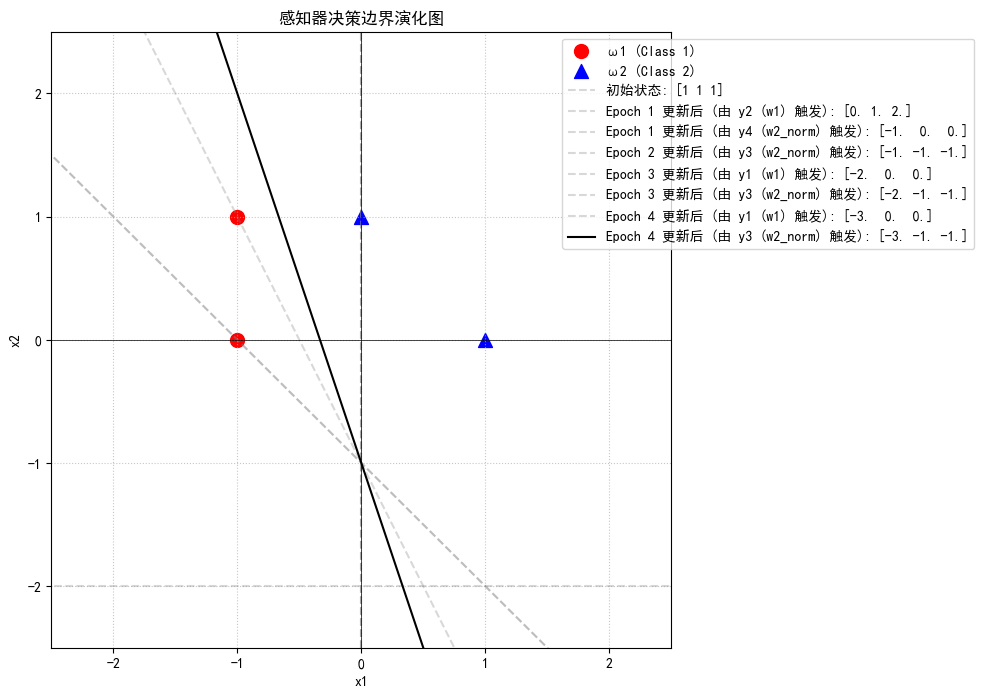

In [6]:
def plot_decision_boundary(w_list, titles, final_only=False):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # 绘制原始样本点
    ax.scatter(X1[:, 0], X1[:, 1], color='red', marker='o', s=100, label='ω1 (Class 1)')
    ax.scatter(X2[:, 0], X2[:, 1], color='blue', marker='^', s=100, label='ω2 (Class 2)')
    
    x_vals = np.linspace(-3, 3, 100)
    
    if final_only:
        w_list = [w_list[-1]]
        titles = [titles[-1]]
        
    # 绘制决策边界演化
    for idx, (w, title) in enumerate(zip(w_list, titles)):
        alpha = 1.0 if idx == len(w_list) - 1 else 0.3 
        color = 'black' if idx == len(w_list) - 1 else 'gray'
        linestyle = '-' if idx == len(w_list) - 1 else '--'
        
        # 修复除零错误：增加对 w[0] == 0 且 w[1] == 0 的处理
        if w[1] != 0:
            y_vals = (-w[0] * x_vals - w[2]) / w[1]
            ax.plot(x_vals, y_vals, color=color, alpha=alpha, linestyle=linestyle, label=f'{title}: {w}')
        elif w[0] != 0:
            # 垂直线
            ax.axvline(x=-w[2]/w[0], color=color, alpha=alpha, linestyle=linestyle, label=f'{title}: {w}')
        else:
            # w[0] 和 w[1] 均为 0，此时方程 0=常数，在二维平面上无直线意义，跳过绘制
            pass

    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title("感知器决策边界演化图" if not final_only else "最终分类决策边界")
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
    ax.grid(True, linestyle=':', alpha=0.7)
    plt.show()

# 绘制历史演化过程
plot_decision_boundary(history_w, history_actions, final_only=False)

## 4. 判别模式向量 $(1, 1)^T$
我们将最终的判别函数应用于测试点，并在最终图表上标注出来。

测试样本 x = [1 1]
代入判别函数 d(x) = -3.0*(1) + (-1.0)*(1) + (-1.0) = -5.0

=> 结论: d(x) < 0，该模式向量属于 ω2 类。


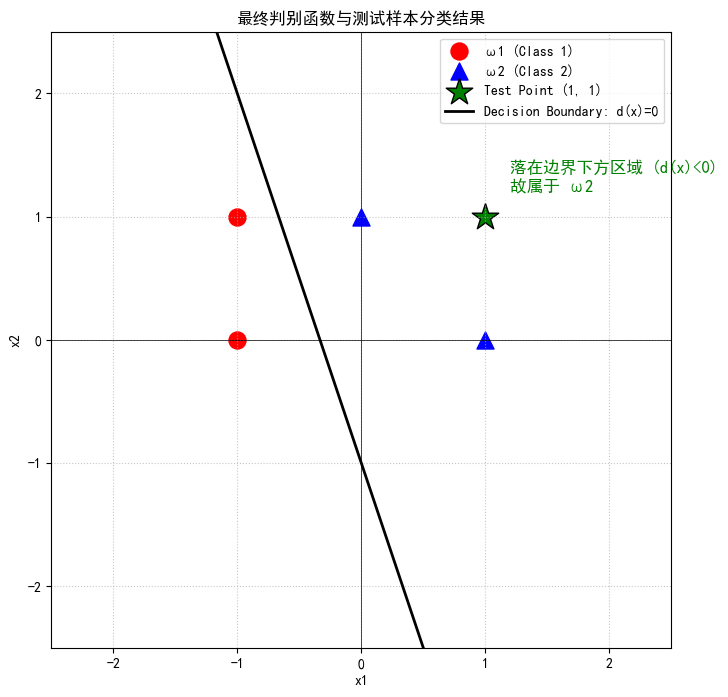

In [5]:
test_x = np.array([1, 1])

# 增广化测试点
test_y = np.array([test_x[0], test_x[1], 1])

# 计算判别函数值
d_val = np.dot(final_w, test_y)

print(f"测试样本 x = {test_x}")
print(f"代入判别函数 d(x) = {final_w[0]}*(1) + ({final_w[1]})*(1) + ({final_w[2]}) = {d_val}")

if d_val > 0:
    print("\n=> 结论: d(x) > 0，该模式向量属于 ω1 类。")
else:
    print("\n=> 结论: d(x) < 0，该模式向量属于 ω2 类。")

# 2. 绘制包含测试点的最终分类图
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X1[:, 0], X1[:, 1], color='red', marker='o', s=150, label='ω1 (Class 1)')
ax.scatter(X2[:, 0], X2[:, 1], color='blue', marker='^', s=150, label='ω2 (Class 2)')

# 绘制测试点
ax.scatter(test_x[0], test_x[1], color='green', marker='*', s=400, edgecolor='black', label='Test Point (1, 1)')

x_vals = np.linspace(-3, 3, 100)
y_vals = (-final_w[0] * x_vals - final_w[2]) / final_w[1]
ax.plot(x_vals, y_vals, color='black', linewidth=2, label=f'Decision Boundary: d(x)=0')

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title("最终判别函数与测试样本分类结果")
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)

# 添加文本注释
ax.text(1.2, 1.2, '落在边界下方区域 (d(x)<0)\n故属于 ω2', fontsize=12, color='green')

plt.show()